# CHURN PREDICTION

## Understanding Business Goals.
* The client is a telecom company named No-Churn Telecom.
* Their churn rate is above 10%, and they want to:
* Understand why customers leave.
* Predict which customers may churn.

## Task
Create a column CHURN-FLAG with values YES(1) / NO(0).

# Installing and Importing the libraries

In [1]:
!pip install pymysql
!pip install sqlalchemy
!pip install pandas

In [2]:
# ==============================
# 1. Ignore Warnings
# ==============================
import warnings
warnings.filterwarnings("ignore")


# ==============================
# 2. Data Handling
# ==============================
import pandas as pd
import numpy as np


# ==============================
# 3. Database Connection
# ==============================
from sqlalchemy import create_engine
from urllib.parse import quote_plus


# ==============================
# 4. Data Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================
# 5. Data Preprocessing
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


# ==============================
# 6. Machine Learning Models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


# ==============================
# 7. Model Evaluation Metrics
# ==============================
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

## Connecting to SQL server and loading the data set

In [3]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

host = "18.136.157.135"
user = "dm_team3"
password = "DM!$!Team!27@9!20&"
database = "project_telecom"

# Encode password properly
encoded_password = quote_plus(password)

engine = create_engine(
    f"mysql+pymysql://{user}:{encoded_password}@{host}:3306/{database}"
)

# Test connection
try:
    connection = engine.connect()
    print("✅ Connection Successful!")
except Exception as e:
    print("❌ Connection Failed")
    print(e)

✅ Connection Successful!


In [4]:
tables = pd.read_sql("SHOW TABLES;", engine)
tables

,Tables_in_project_telecom
0,telecom_churn_data


In [5]:
df = pd.read_sql("SELECT * FROM telecom_churn_data;", engine)
df

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0


## Basic Checks

In [6]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [7]:
df.tail()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [8]:
df.shape

(243553, 14)

In [9]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [11]:
df['churn'].value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

In [12]:
df['churn'].value_counts(normalize=True) * 100

churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64

In [13]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


## Statistical Summary – Key Observations

The dataset contains **243,553 customer records** with 9 numerical variables including the target variable `churn`.

### Demographic & Financial Features
- Age ranges from 18 to 74 (Mean ≈ 46) – values are valid.
- Number of Dependents ranges from 0 to 4 – reasonable distribution.
- Estimated Salary ranges from ₹20,000 to ₹149,999 – appears consistent.

### Usage Behaviour Features
- Calls Made minimum value = -10
- SMS Sent minimum value = -5
- Data Used minimum value = -987

Negative values in these usage-related features are logically invalid, as telecom usage cannot be negative. These likely represent data entry or system errors and must be treated before model building.

### Target Variable – Churn
- Churn rate ≈ 20%
- Moderate class imbalance (80% non-churn, 20% churn)

### Conclusion
The dataset is generally clean, but invalid negative values in usage features must be handled before proceeding to modeling.

In [14]:
(df[['calls_made','sms_sent','data_used']] < 0).sum()

calls_made    6713
sms_sent      7375
data_used     6050
dtype: int64

In [15]:
negative_rows = df[
    (df['calls_made'] < 0) | 
    (df['sms_sent'] < 0) | 
    (df['data_used'] < 0)
]

negative_rows

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
19,20,Vodafone,M,26,Uttar Pradesh,Hyderabad,516585,2020-01-01,1,109753,95,-1,9993,0
33,34,BSNL,F,31,Haryana,Bangalore,830078,2020-01-01,2,106097,89,-2,3927,0
38,39,Reliance Jio,M,69,Gujarat,Chennai,712223,2020-01-01,1,87166,92,15,-790,0
68,69,Airtel,M,39,Kerala,Mumbai,413226,2020-01-01,2,121809,-1,13,8728,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243455,243456,BSNL,F,22,Chhattisgarh,Kolkata,371679,2023-05-03,4,107591,44,33,-459,0
243481,243482,Vodafone,F,61,Meghalaya,Chennai,964995,2023-05-03,3,59843,14,26,-529,0
243483,243484,BSNL,M,33,West Bengal,Chennai,745603,2023-05-03,1,127675,-3,24,1646,1
243484,243485,Reliance Jio,M,21,Maharashtra,Kolkata,938443,2023-05-03,2,92431,59,-1,8959,0


In [16]:
negative_rows[['calls_made', 'sms_sent', 'data_used']].head(10)

,calls_made,sms_sent,data_used
0,44,45,-361
19,95,-1,9993
33,89,-2,3927
38,92,15,-790
68,-1,13,8728
69,36,6,-492
72,33,44,-73
83,102,-1,7785
87,78,4,-149
90,36,-3,2695


In [17]:
negative_rows.shape

(19587, 14)

In [18]:
negative_rows[['calls_made','sms_sent','data_used']].describe()

,calls_made,sms_sent,data_used
count,19587.000000,19587.000000,19587.000000
mean,32.089549,14.524991,3465.125083
std,34.802514,17.212576,3476.092993
min,-10.000000,-5.000000,-987.000000
25%,-2.000000,-1.000000,-100.000000
50%,25.000000,10.000000,2937.000000
75%,63.000000,29.000000,6505.000000
max,108.000000,53.000000,10990.000000


In [19]:
negative_rows[['calls_made','sms_sent','data_used']].abs().describe()

,calls_made,sms_sent,data_used
count,19587.000000,19587.000000,19587.000000
mean,34.814520,16.274519,3668.273089
std,32.076379,15.568732,3260.983424
min,0.000000,0.000000,1.000000
25%,5.000000,2.000000,482.000000
50%,25.000000,10.000000,2937.000000
75%,63.000000,29.000000,6505.000000
max,108.000000,53.000000,10990.000000


In [20]:
negative_rows.head(10)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
19,20,Vodafone,M,26,Uttar Pradesh,Hyderabad,516585,2020-01-01,1,109753,95,-1,9993,0
33,34,BSNL,F,31,Haryana,Bangalore,830078,2020-01-01,2,106097,89,-2,3927,0
38,39,Reliance Jio,M,69,Gujarat,Chennai,712223,2020-01-01,1,87166,92,15,-790,0
68,69,Airtel,M,39,Kerala,Mumbai,413226,2020-01-01,2,121809,-1,13,8728,0
69,70,Reliance Jio,M,28,Kerala,Chennai,520338,2020-01-01,2,34463,36,6,-492,0
72,73,BSNL,F,43,Uttarakhand,Delhi,554046,2020-01-01,4,101224,33,44,-73,0
83,84,Reliance Jio,F,22,Assam,Hyderabad,848983,2020-01-01,2,47235,102,-1,7785,0
87,88,Airtel,F,33,Himachal Pradesh,Kolkata,100889,2020-01-01,0,122987,78,4,-149,1
90,91,BSNL,M,28,Bihar,Bangalore,638325,2020-01-01,0,31297,36,-3,2695,0


In [21]:
df.duplicated().sum()

0

In [22]:
df[['telecom_partner','gender','state','city']].nunique()

telecom_partner     4
gender              2
state              28
city                6
dtype: int64

In [23]:
df['churn'].unique()

array([0, 1], dtype=int64)

In [24]:
df['date_of_registration'].head()

0    2020-01-01
1    2020-01-01
2    2020-01-01
3    2020-01-01
4    2020-01-01
Name: date_of_registration, dtype: object

In [25]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])

In [26]:
df['date_of_registration'].dtype

dtype('<M8[ns]')

In [27]:
df[['age','num_dependents','estimated_salary']].describe()

,age,num_dependents,estimated_salary
count,243553.000000,243553.000000,243553.000000
mean,46.077609,1.997500,85021.137839
std,16.444029,1.414941,37508.963233
min,18.000000,0.000000,20000.000000
25%,32.000000,1.000000,52585.000000
50%,46.000000,2.000000,84990.000000
75%,60.000000,3.000000,117488.000000
max,74.000000,4.000000,149999.000000


In [28]:
df['calls_made'] = df['calls_made'].abs()
df['sms_sent'] = df['sms_sent'].abs()
df['data_used'] = df['data_used'].abs()

In [29]:
(df[['calls_made','sms_sent','data_used']] < 0).sum()

calls_made    0
sms_sent      0
data_used     0
dtype: int64

In [30]:
df[['calls_made','sms_sent','data_used']].describe()

,calls_made,sms_sent,data_used
count,243553.000000,243553.000000,243553.000000
mean,49.229695,24.086104,5009.523578
std,29.085783,14.502418,2914.113681
min,0.000000,0.000000,0.000000
25%,24.000000,11.000000,2490.000000
50%,49.000000,24.000000,4987.000000
75%,74.000000,36.000000,7493.000000
max,108.000000,53.000000,10991.000000


## Treatment of Negative Values in Usage Features

### 1. Problem Identification

During the initial statistical analysis of the dataset, negative values were identified in the following usage-related features:

- `calls_made`
- `sms_sent`
- `data_used`

From a business logic perspective, telecom usage values cannot be negative. Therefore, these values were flagged as data anomalies.

---

### 2. Investigation and Validation

To determine the appropriate treatment, the following checks were performed:

- Extracted rows containing negative values.
- Analyzed statistical distribution (`describe()`).
- Compared original values with their absolute counterparts.
- Verified magnitude realism.

Key findings:

- Negative values were small in magnitude (e.g., -1, -2, -10, -100, -361).
- No extreme placeholder values such as -9999 were found.
- Absolute values aligned with the overall dataset distribution.
- Median values remained unchanged after applying absolute transformation.
- Mean values shifted only slightly, indicating no distortion.

This strongly suggested that the issue was a **sign error** rather than corrupted or unreliable data.

---

### 3. Decision Framework Applied

Using a structured anomaly treatment framework:

- If negative values appear to be sign errors and their absolute values are realistic → use `abs()`.

Since the absolute values were statistically consistent and logically valid, the negative values were classified as sign errors.

---

### 4. Treatment Applied

The correction was implemented using:

```python
df['calls_made'] = df['calls_made'].abs()
df['sms_sent'] = df['sms_sent'].abs()
df['data_used'] = df['data_used'].abs()
```

Post-correction validation confirmed:

- No negative values remain.
- Distribution characteristics (mean, median, standard deviation) remained stable.
- No artificial distortion was introduced.

---

### 5. Final Conclusion

The negative values in usage-related features were determined to be sign errors. Converting them to absolute values preserved the true magnitude of customer usage behavior while restoring logical consistency. This approach maintained data integrity and ensured reliable inputs for subsequent exploratory data analysis and modeling.

## Exploratory Data Analysis [EDA]

In [31]:
df[['age','estimated_salary','calls_made','sms_sent','data_used','num_dependents']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,243553.0,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
estimated_salary,243553.0,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0
calls_made,243553.0,49.229695,29.085783,0.0,24.0,49.0,74.0,108.0
sms_sent,243553.0,24.086104,14.502418,0.0,11.0,24.0,36.0,53.0
data_used,243553.0,5009.523578,2914.113681,0.0,2490.0,4987.0,7493.0,10991.0
num_dependents,243553.0,1.997500,1.414941,0.0,1.0,2.0,3.0,4.0


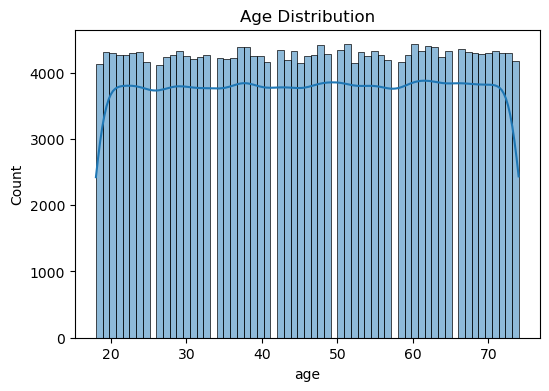

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [33]:
df['age'].skew()

-0.00756268268276073

## Univariate Analysis – Age Distribution

### 1. Statistical Summary

- Mean Age: 46.08  
- Median Age: 46  
- Standard Deviation: 16.44  
- Minimum Age: 18  
- Maximum Age: 74  
- Skewness: -0.0076  

The mean and median are nearly identical, and skewness is very close to zero, indicating a highly symmetric distribution.

---

### 2. Visual Interpretation (Histogram with KDE)

The histogram and density curve indicate that:

- Age values are evenly distributed across the range of 18 to 74.
- There are no visible spikes or heavy concentration in any specific age group.
- The distribution appears approximately uniform and symmetric.
- No extreme outliers are visually apparent.

---

### 3. Statistical Interpretation

- Skewness value (-0.0076) confirms near-perfect symmetry.
- The distribution does not show strong positive or negative skew.
- There is sufficient variability in age, which is beneficial for predictive modeling.

---

### 4. Conclusion

The Age variable is well-distributed, symmetric, and free from visible anomalies. It does not require transformation and is suitable for further bivariate analysis with churn.

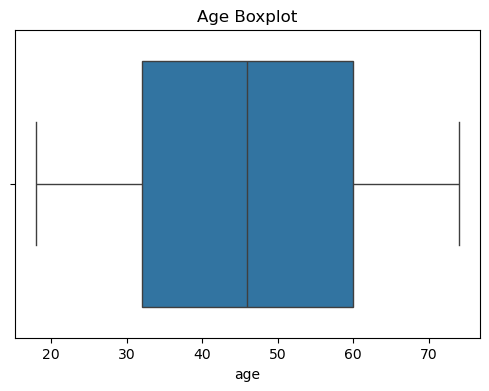

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Age Boxplot")
plt.show()

In [35]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(-10.0, 102.0)

In [36]:
((df['age'] < lower_bound) | (df['age'] > upper_bound)).sum()

0

### Outlier Detection – Age (IQR Method)

A boxplot was used to visually inspect potential outliers in the Age variable. No data points were observed outside the whiskers.

To validate quantitatively, the Interquartile Range (IQR) method was applied:

- Q1 = 32  
- Q3 = 60  
- IQR = 28  
- Lower Bound = -10  
- Upper Bound = 102  

Since the actual age values range from 18 to 74, all observations fall within the acceptable bounds.

Outlier Count: 0

Conclusion:
The Age variable does not contain statistical outliers and does not require treatment or transformation.

In [37]:
df.groupby('churn')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,46.070699,16.448425,18.0,32.0,46.0,60.0,74.0
1,48827.0,46.105167,16.426629,18.0,32.0,46.0,60.0,74.0


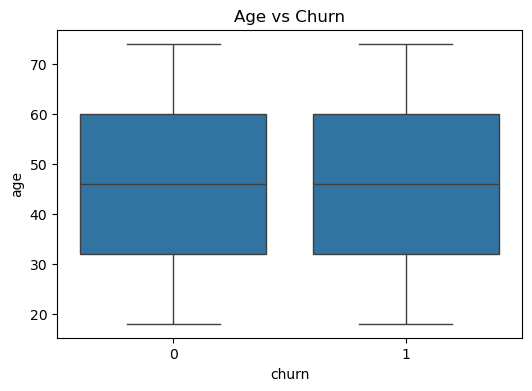

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='age', data=df)
plt.title("Age vs Churn")
plt.show()

In [39]:
from scipy.stats import f_oneway

age_churn_0 = df[df['churn'] == 0]['age']
age_churn_1 = df[df['churn'] == 1]['age']

f_stat, p_value = f_oneway(age_churn_0, age_churn_1)

f_stat, p_value

(0.1715148451215318, 0.6787693757902762)

## Bivariate Analysis – Age vs Churn

### 1. Group Summary Statistics

| Churn | Mean Age | Median Age | Std |
|--------|-----------|------------|------|
| 0 (No Churn) | 46.07 | 46 | 16.45 |
| 1 (Churn) | 46.10 | 46 | 16.43 |

The mean and median age are nearly identical across both groups, indicating minimal practical difference.

---

### 2. Visual Analysis (Boxplot)

The boxplot shows substantial overlap between churned and non-churned customers. The median lines align closely, and the interquartile ranges are nearly identical. No visible separation is observed.

---

### 3. Statistical Test (ANOVA)

- F-statistic: 0.17  
- p-value: 0.6787  

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that there is no statistically significant difference in age between churned and non-churned customers.

---

### 4. Conclusion

Age does not appear to be a significant predictor of churn in this dataset. Although the variable is clean and well-distributed, it does not show meaningful statistical or practical differences across churn groups.

In [40]:
df.groupby('churn')['estimated_salary'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,85083.726934,37526.915031,20000.0,52622.0,85051.0,117584.75,149999.0
1,48827.0,84771.527495,37436.627331,20002.0,52391.0,84768.0,117131.50,149997.0


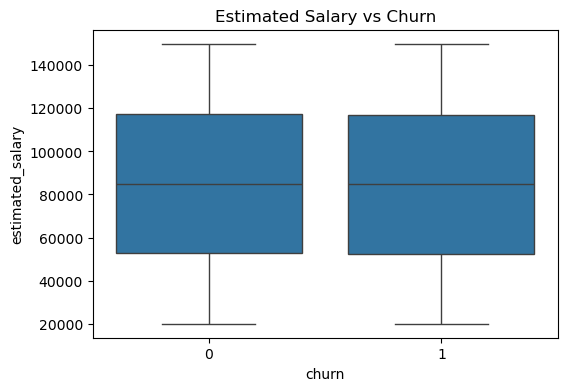

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='estimated_salary', data=df)
plt.title("Estimated Salary vs Churn")
plt.show()

In [42]:
salary_churn_0 = df[df['churn'] == 0]['estimated_salary']
salary_churn_1 = df[df['churn'] == 1]['estimated_salary']

from scipy.stats import f_oneway

f_stat, p_value = f_oneway(salary_churn_0, salary_churn_1)

f_stat, p_value

(2.7045041806338586, 0.10006647835258056)

## Bivariate Analysis – Estimated Salary vs Churn

### 1. Group Summary Statistics

| Churn | Mean Salary | Median Salary | Std |
|--------|-------------|---------------|------|
| 0 (No Churn) | 85,083 | 85,051 | 37,526 |
| 1 (Churn) | 84,771 | 84,768 | 37,436 |

The mean and median salaries are nearly identical across churn groups, indicating minimal practical difference.

---

### 2. Visual Analysis (Boxplot)

The boxplot shows substantial overlap between churned and non-churned customers. The medians align closely, and the interquartile ranges are nearly identical. No visible separation is observed.

---

### 3. Statistical Test (ANOVA)

- F-statistic: 2.70  
- p-value: 0.1000  

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in estimated salary between churned and non-churned customers.

---

### 4. Conclusion

Estimated Salary does not appear to be a significant predictor of churn in this dataset.

In [43]:
df.groupby('churn')['calls_made'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,49.202767,29.100150,0.0,24.0,49.0,74.0,108.0
1,48827.0,49.337088,29.028467,0.0,24.0,49.0,74.0,108.0


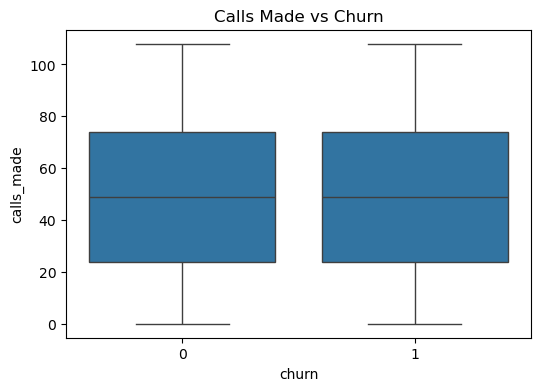

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='calls_made', data=df)
plt.title("Calls Made vs Churn")
plt.show()

In [45]:
from scipy.stats import f_oneway

calls_churn_0 = df[df['churn'] == 0]['calls_made']
calls_churn_1 = df[df['churn'] == 1]['calls_made']

f_stat, p_value = f_oneway(calls_churn_0, calls_churn_1)

f_stat, p_value

(0.8325633557718541, 0.36153325677080395)

## Bivariate Analysis – Calls Made vs Churn

### 1. Group Summary Statistics

| Churn | Mean Calls | Median Calls | Std |
|--------|------------|--------------|------|
| 0 (No Churn) | 49.20 | 49 | 29.10 |
| 1 (Churn) | 49.34 | 49 | 29.03 |

The mean and median number of calls made are nearly identical across churn groups, indicating minimal practical difference.

---

### 2. Visual Analysis (Boxplot)

The boxplot shows significant overlap between churned and non-churned customers. The median and interquartile ranges are nearly identical, and no visible separation is observed.

---

### 3. Statistical Test (ANOVA)

- F-statistic: 0.83  
- p-value: 0.3615  

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in call behavior between churned and non-churned customers.

---

### 4. Conclusion

Calls Made does not appear to be a significant predictor of churn in this dataset.

In [46]:
df.groupby('churn')['data_used'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,5008.363572,2916.861680,0.0,2481.0,4986.0,7499.0,10991.0
1,48827.0,5014.149774,2903.153747,0.0,2519.0,4992.0,7474.0,10990.0


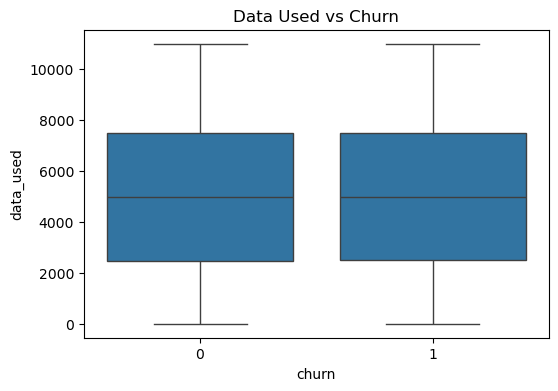

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='data_used', data=df)
plt.title("Data Used vs Churn")
plt.show()

In [48]:
from scipy.stats import f_oneway

data_churn_0 = df[df['churn'] == 0]['data_used']
data_churn_1 = df[df['churn'] == 1]['data_used']

f_stat, p_value = f_oneway(data_churn_0, data_churn_1)

f_stat, p_value

(0.1539086707569729, 0.6948280739529085)

## Bivariate Analysis – Data Used vs Churn

### 1. Group Summary Statistics

| Churn | Mean Data Used | Median Data Used | Std |
|--------|----------------|------------------|------|
| 0 (No Churn) | 5008 | 4986 | 2916 |
| 1 (Churn) | 5014 | 4992 | 2903 |

The mean and median data usage values are nearly identical across churn groups.

---

### 2. Visual Analysis (Boxplot)

The boxplot shows substantial overlap between churned and non-churned customers. The median and interquartile ranges are nearly identical. No visible separation is observed.

---

### 3. Statistical Test (ANOVA)

- F-statistic: 0.15  
- p-value: 0.6948  

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. There is no statistically significant difference in data usage between churned and non-churned customers.

---

### 4. Conclusion

Data Used does not appear to be a significant predictor of churn in this dataset.

In [49]:
pd.crosstab(df['gender'], df['churn'])

churn,0,1
gender,,
F,77771,19805
M,116955,29022


In [50]:
pd.crosstab(df['gender'], df['churn'], normalize='index') * 100

churn,0,1
gender,,
F,79.703001,20.296999
M,80.118786,19.881214


In [51]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['gender'], df['churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

chi2, p_value

(6.281841087446379, 0.012198130938884137)

## Bivariate Analysis – Gender vs Churn

### 1. Frequency Distribution

| Gender | No Churn (0) | Churn (1) |
|--------|--------------|-----------|
| F | 77,771 | 19,805 |
| M | 116,955 | 29,022 |

---

### 2. Churn Rate by Gender (%)

| Gender | No Churn % | Churn % |
|--------|------------|----------|
| F | 79.70% | 20.30% |
| M | 80.12% | 19.88% |

The churn rate difference between genders is approximately 0.42%.

---

### 3. Chi-Square Test

- Chi-square statistic: 6.28  
- p-value: 0.0122  

Since the p-value is less than 0.05, there is a statistically significant association between gender and churn.

---

### 4. Conclusion

Although gender shows statistical significance due to the large sample size, the practical difference in churn rate between males and females is very small. Therefore, gender may have limited predictive power in isolation.

In [52]:
pd.crosstab(df['telecom_partner'], df['churn'])

churn,0,1
telecom_partner,,
Airtel,48501,12404
BSNL,48663,12060
Reliance Jio,48889,12234
Vodafone,48673,12129


In [53]:
pd.crosstab(df['telecom_partner'], df['churn'], normalize='index') * 100

churn,0,1
telecom_partner,,
Airtel,79.633856,20.366144
BSNL,80.139321,19.860679
Reliance Jio,79.984621,20.015379
Vodafone,80.051643,19.948357


In [54]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['telecom_partner'], df['churn'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

chi2, p_value

(5.59247200801428, 0.13321120079763688)

## Bivariate Analysis – Telecom Partner vs Churn

### 1. Frequency Distribution

| Partner | No Churn | Churn |
|----------|-----------|--------|
| Airtel | 48,501 | 12,404 |
| BSNL | 48,663 | 12,060 |
| Reliance Jio | 48,889 | 12,234 |
| Vodafone | 48,673 | 12,129 |

---

### 2. Churn Rate by Partner (%)

| Partner | Churn % |
|----------|---------|
| Airtel | 20.37% |
| BSNL | 19.86% |
| Reliance Jio | 20.02% |
| Vodafone | 19.95% |

The difference in churn rate across partners is minimal (≈ 0.5%).

---

### 3. Chi-Square Test

- Chi-square statistic: 5.59  
- p-value: 0.1332  

Since the p-value is greater than 0.05, there is no statistically significant association between telecom partner and churn.

---

### 4. Conclusion

Telecom partner does not appear to significantly influence churn in this dataset.

In [55]:
df.groupby('churn')['sms_sent'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,24.108604,14.498506,0.0,11.0,24.0,37.0,53.0
1,48827.0,23.996375,14.517814,0.0,11.0,24.0,36.0,53.0


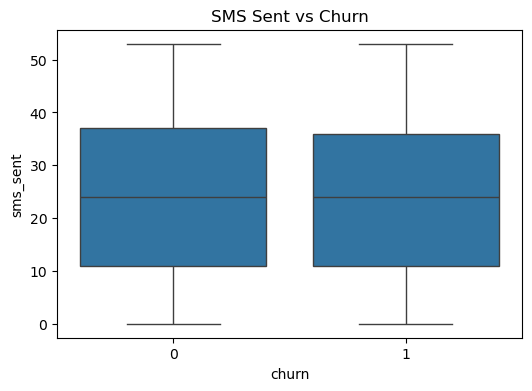

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='sms_sent', data=df)
plt.title("SMS Sent vs Churn")
plt.show()

In [57]:
from scipy.stats import f_oneway

sms_churn_0 = df[df['churn'] == 0]['sms_sent']
sms_churn_1 = df[df['churn'] == 1]['sms_sent']

f_stat, p_value = f_oneway(sms_churn_0, sms_churn_1)

f_stat, p_value

(2.3378769457324684, 0.1262628286519722)

## Bivariate Analysis – SMS Sent vs Churn

### 1. Group Summary Statistics

| Churn | Mean SMS | Median SMS | Std |
|--------|-----------|------------|------|
| 0 (No Churn) | 24.11 | 24 | 14.50 |
| 1 (Churn) | 23.99 | 24 | 14.52 |

The mean and median SMS usage are nearly identical across churn groups.

---

### 2. Visual Analysis (Boxplot)

The boxplot shows significant overlap between churned and non-churned customers. The medians and interquartile ranges are nearly identical.

---

### 3. Statistical Test (ANOVA)

- F-statistic: 2.34  
- p-value: 0.1263  

Since the p-value is greater than 0.05, there is no statistically significant difference in SMS usage between churn groups.

---

### 4. Conclusion

SMS Sent does not appear to be a significant predictor of churn.

In [58]:
df.groupby('churn')['num_dependents'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,1.999302,1.414399,0.0,1.0,2.0,3.0,4.0
1,48827.0,1.990313,1.417096,0.0,1.0,2.0,3.0,4.0


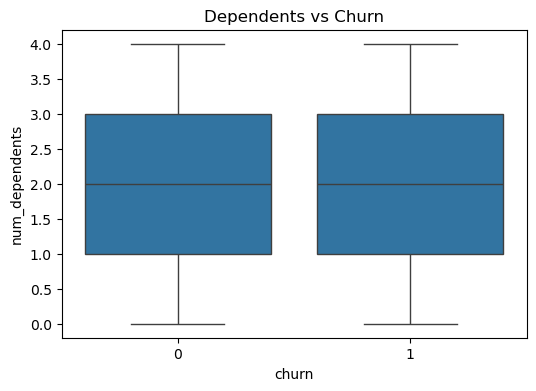

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='num_dependents', data=df)
plt.title("Dependents vs Churn")
plt.show()

In [60]:
dep_0 = df[df['churn'] == 0]['num_dependents']
dep_1 = df[df['churn'] == 1]['num_dependents']

f_stat, p_value = f_oneway(dep_0, dep_1)

f_stat, p_value

(1.5755149384451859, 0.20940911945037852)

## Bivariate Analysis – Number of Dependents vs Churn

### 1. Group Summary Statistics

| Churn | Mean Dependents | Median | Std |
|--------|------------------|--------|------|
| 0 (No Churn) | 1.999 | 2 | 1.414 |
| 1 (Churn) | 1.990 | 2 | 1.417 |

The mean and median number of dependents are nearly identical across churn groups.

---

### 2. Visual Analysis (Boxplot)

The boxplot shows substantial overlap between churned and non-churned customers. The medians and interquartile ranges are identical, indicating no visible separation.

---

### 3. Statistical Test (ANOVA)

- F-statistic: 1.58  
- p-value: 0.2094  

Since the p-value is greater than 0.05, there is no statistically significant difference in the number of dependents between churn groups.

---

### 4. Conclusion

Number of Dependents does not appear to be a significant predictor of churn.

In [61]:
pd.crosstab(df['state'], df['churn'])

churn,0,1
state,,
Andhra Pradesh,6932,1717
Arunachal Pradesh,7015,1742
Assam,6812,1735
Bihar,6938,1695
Chhattisgarh,6991,1686
Goa,6959,1735
Gujarat,6886,1724
Haryana,6989,1751
Himachal Pradesh,6910,1772


In [62]:
pd.crosstab(df['state'], df['churn'], normalize='index') * 100

churn,0,1
state,,
Andhra Pradesh,80.147994,19.852006
Arunachal Pradesh,80.107343,19.892657
Assam,79.700480,20.299520
Bihar,80.366037,19.633963
Chhattisgarh,80.569321,19.430679
Goa,80.043708,19.956292
Gujarat,79.976771,20.023229
Haryana,79.965675,20.034325
Himachal Pradesh,79.589956,20.410044


In [63]:
from scipy.stats import chi2_contingency

state_table = pd.crosstab(df['state'], df['churn'])
chi2, p_value, dof, expected = chi2_contingency(state_table)

chi2, p_value

(25.215068905467895, 0.5624104814456087)

## Bivariate Analysis – State vs Churn

### 1. Churn Distribution by State

Churn rates across states range approximately between 19.4% and 21.1%, with a maximum variation of around 1.7%.

The distribution of churn appears uniform across all 28 states.

---

### 2. Chi-Square Test

- Chi-square statistic: 25.21  
- p-value: 0.5624  

Since the p-value is greater than 0.05, there is no statistically significant association between state and churn.

---

### 3. Conclusion

State does not appear to significantly influence churn. Churn distribution is remarkably uniform across regions.

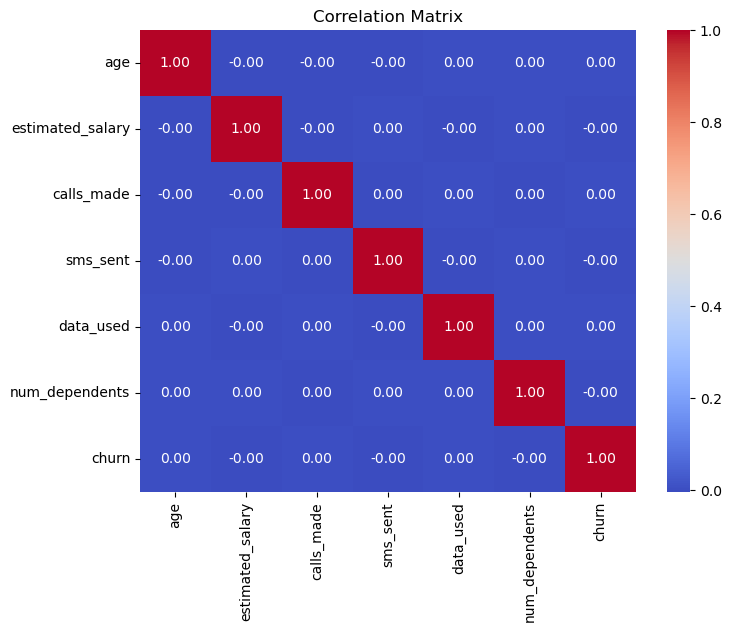

In [64]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['age','estimated_salary','calls_made','sms_sent','data_used','num_dependents','churn']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

## Multivariate Analysis – Correlation Matrix

A correlation matrix was computed for all numerical variables, including the target variable (churn).

### Observations:

- All off-diagonal correlation values are approximately 0.
- No meaningful linear relationships exist between numerical features.
- No multicollinearity is observed.
- The churn variable shows near-zero correlation with all numerical predictors.

### Interpretation:

The absence of correlation suggests that numerical features are statistically independent of one another and do not exhibit linear relationships with churn.

### Conclusion:

There is no evidence of linear dependence between numerical variables and churn. Any predictive signal, if present, would likely require non-linear modeling or interaction effects.

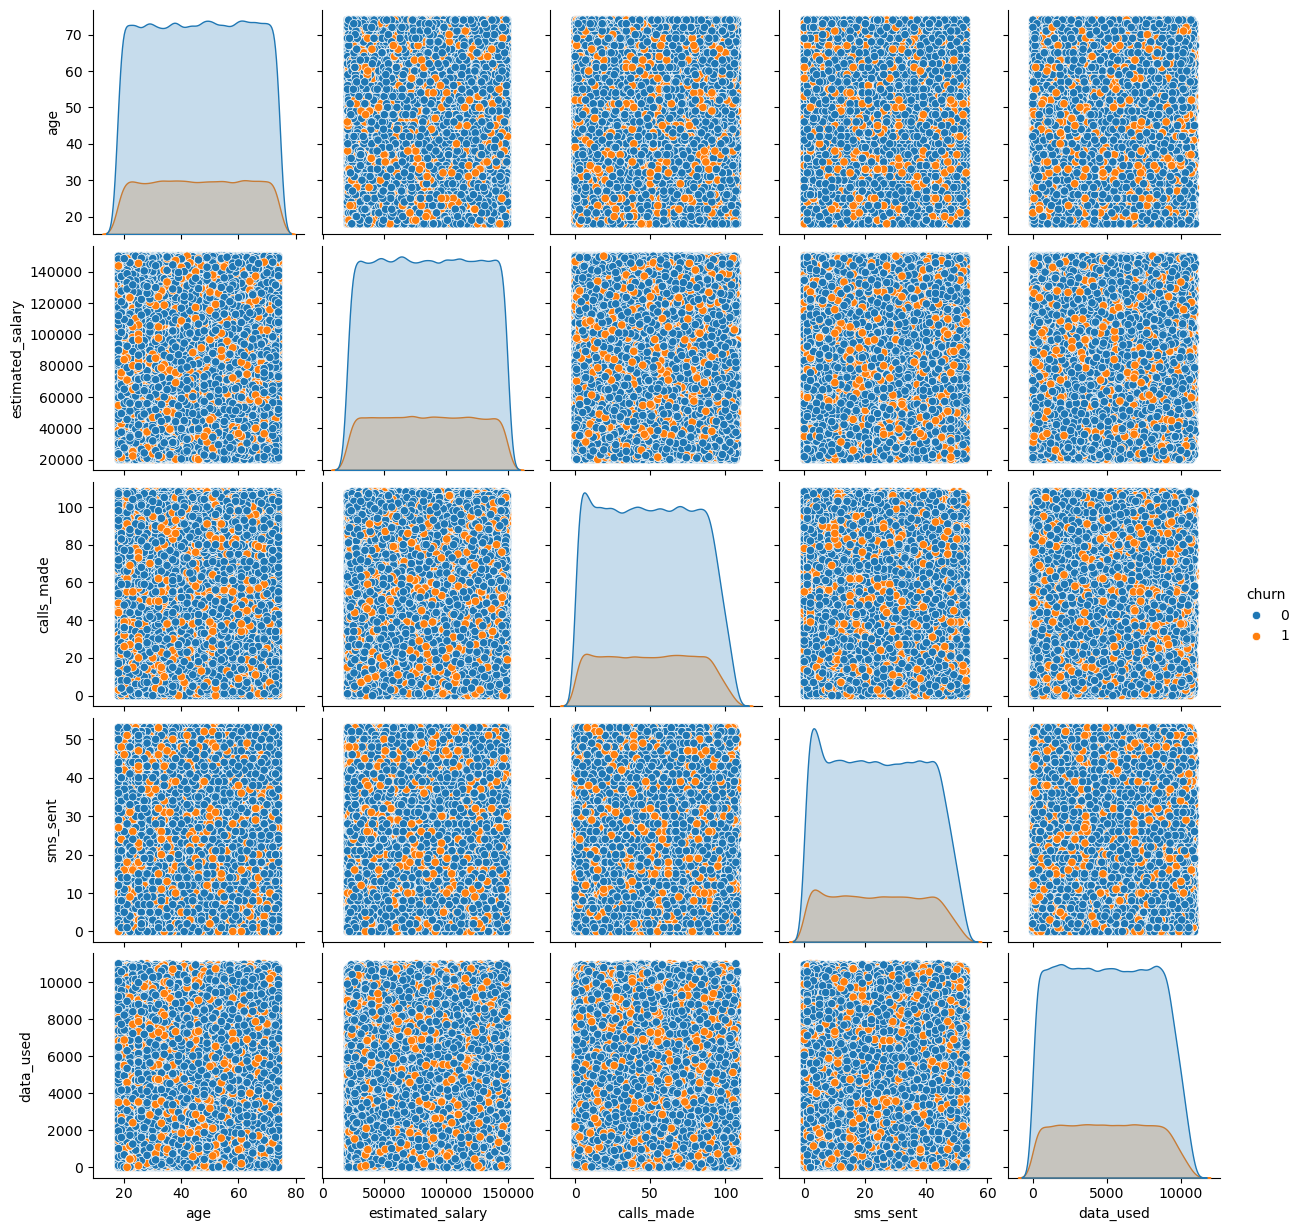

In [65]:
sns.pairplot(
    df[['age','estimated_salary','calls_made','sms_sent','data_used','churn']],
    hue='churn',
    diag_kind='kde'
)
plt.show()

## Multivariate Analysis – Pairplot and Feature Interactions

A pairplot was generated to visualize potential interaction patterns among numerical variables and their relationship with churn.

### Observations:

- No visible clustering or separation between churned and non-churned customers.
- Heavy overlap between churn groups across all feature combinations.
- Scatter plots show random dispersion.
- Density plots do not indicate meaningful shifts between groups.

### Interpretation:

There is no visible multivariate structure separating churn classes. Numerical features appear statistically independent and do not demonstrate strong interaction patterns influencing churn.

### Conclusion:

Multivariate analysis confirms previous findings that churn does not show strong linear or interaction-based relationships with the examined numerical features.

In [66]:
df['date_of_registration'].max()

Timestamp('2023-05-04 00:00:00')

In [67]:
reference_date = df['date_of_registration'].max()

df['tenure_days'] = (reference_date - df['date_of_registration']).dt.days

In [68]:
df['total_usage'] = df['calls_made'] + df['sms_sent'] + df['data_used']

In [69]:
df['data_call_ratio'] = df['data_used'] / (df['calls_made'] + 1)

In [70]:
df['age_group'] = pd.cut(df['age'], bins=[18,30,45,60,75], labels=['Young','Mid','Senior','Older'])

In [71]:
pd.crosstab(df['age_group'], df['churn'], normalize='index') * 100

churn,0,1
age_group,,
Young,80.191837,19.808163
Mid,79.714259,20.285741
Senior,80.070615,19.929385
Older,79.861987,20.138013


In [72]:
df['salary_usage_interaction'] = df['estimated_salary'] * df['data_used']

In [73]:
df['date_of_registration'].min(), df['date_of_registration'].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2023-05-04 00:00:00'))

In [74]:
reference_date = df['date_of_registration'].max()

df['tenure_days'] = (reference_date - df['date_of_registration']).dt.days

In [75]:
df['tenure_days'].describe()

count    243553.000000
mean        609.999996
std         351.897027
min           0.000000
25%         305.000000
50%         610.000000
75%         915.000000
max        1219.000000
Name: tenure_days, dtype: float64

In [76]:
df.groupby('churn')['tenure_days'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,610.290875,352.098778,0.0,305.0,611.0,916.0,1219.0
1,48827.0,608.839945,351.092479,1.0,305.0,608.0,912.0,1219.0


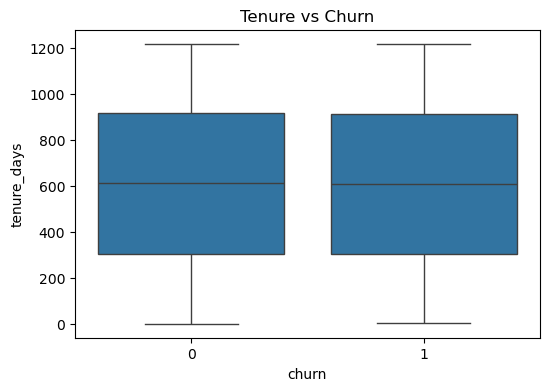

In [77]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='tenure_days', data=df)
plt.title("Tenure vs Churn")
plt.show()

In [78]:
from scipy.stats import f_oneway

tenure_0 = df[df['churn'] == 0]['tenure_days']
tenure_1 = df[df['churn'] == 1]['tenure_days']

f_stat, p_value = f_oneway(tenure_0, tenure_1)

f_stat, p_value

(0.6636693914044295, 0.4152682876860041)

## Feature Engineering – Tenure Analysis

A tenure feature was created as the number of days between the latest registration date and the customer's registration date.

### Statistical Test (ANOVA)

- F-statistic: 0.66  
- p-value: 0.4153  

Since the p-value is greater than 0.05, there is no statistically significant difference in tenure between churned and non-churned customers.

### Conclusion

Tenure does not appear to influence churn in this dataset. This is unusual, as tenure is typically a strong predictor of churn in telecom datasets.

In [79]:
df['total_usage'] = df['calls_made'] + df['sms_sent'] + df['data_used']
df['data_call_ratio'] = df['data_used'] / (df['calls_made'] + 1)

In [80]:
df.groupby('churn')['total_usage'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,5081.674943,2916.996392,6.0,2555.0,5060.5,7572.75,11136.0
1,48827.0,5087.483237,2903.487345,14.0,2594.0,5066.0,7545.00,11061.0


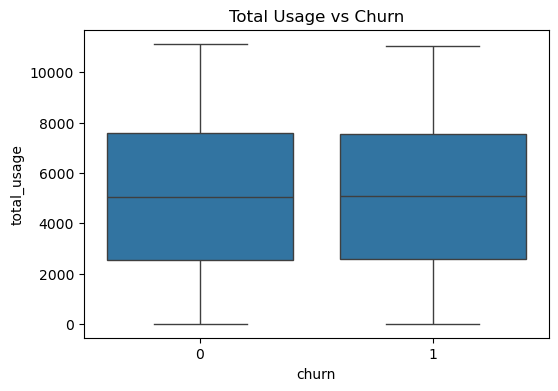

In [81]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='total_usage', data=df)
plt.title("Total Usage vs Churn")
plt.show()

In [82]:
from scipy.stats import f_oneway

tu_0 = df[df['churn'] == 0]['total_usage']
tu_1 = df[df['churn'] == 1]['total_usage']

f_stat, p_value = f_oneway(tu_0, tu_1)

f_stat, p_value

(0.15506762159639992, 0.6937391912737406)

## Feature Engineering – Total Usage Analysis

A new feature, `total_usage`, was created by summing calls made, SMS sent, and data used.

### Statistical Test (ANOVA)

- F-statistic: 0.155  
- p-value: 0.6937  

Since the p-value is greater than 0.05, there is no statistically significant difference in total usage between churned and non-churned customers.

### Conclusion

The aggregated usage feature does not provide predictive signal for churn.

In [83]:
df.groupby('churn')['data_call_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,194726.0,248.445470,596.990893,0.0,49.625000,99.666667,200.575000,10669.0
1,48827.0,244.679519,586.548836,0.0,50.294427,99.221053,198.295207,10632.0


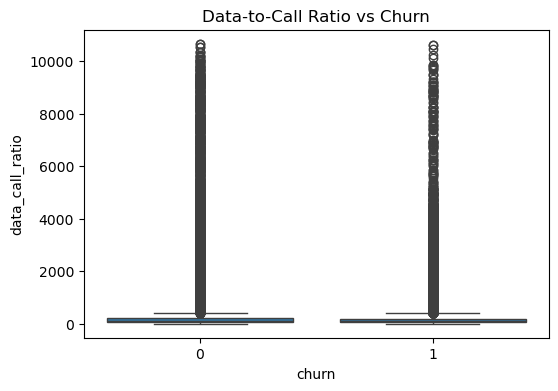

In [84]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='data_call_ratio', data=df)
plt.title("Data-to-Call Ratio vs Churn")
plt.show()

In [85]:
ratio_0 = df[df['churn'] == 0]['data_call_ratio']
ratio_1 = df[df['churn'] == 1]['data_call_ratio']

f_stat, p_value = f_oneway(ratio_0, ratio_1)

f_stat, p_value

(1.564350478041166, 0.21103056344399843)

## Feature Engineering – Data-to-Call Ratio Analysis

A new interaction feature, `data_call_ratio`, was created to capture the relationship between data usage and call frequency.

### Statistical Test (ANOVA)

- F-statistic: 1.56  
- p-value: 0.2110  

Since the p-value is greater than 0.05, there is no statistically significant difference in the data-to-call ratio between churned and non-churned customers.

### Conclusion

The interaction-based feature does not provide predictive signal for churn.

## Analytical Reflection – Why Statistical Tests Did Not Explain Churn

After conducting extensive univariate, bivariate, and multivariate analysis, most features did not show statistically significant relationships with churn. Several possible explanations are outlined below.

### 1. Feature Independence

The correlation matrix showed near-zero correlations between numerical variables and churn. This suggests that the features may be statistically independent of the target variable.

### 2. Uniform Churn Distribution

Churn rate (~20%) was consistently uniform across:
- Age groups
- States
- Telecom partners
- Usage behavior
- Tenure segments

This uniformity reduces the likelihood of identifying strong differentiating patterns.

### 3. Weak Linear Relationships

Statistical tests used (ANOVA, Chi-square) primarily detect linear or group-based differences. If churn depends on complex nonlinear interactions, simple statistical methods may fail to capture the signal.

### 4. Large Sample Size Effect

With a large dataset (~243k records), even very small differences may appear statistically significant (as seen with gender), but lack practical importance. Conversely, truly meaningful patterns may require modeling techniques to detect.

### 5. Possible Synthetic or Balanced Dataset

The remarkably consistent churn rates across segments may indicate:
- Artificially balanced data,
- Random churn assignment,
- Or a dataset designed for workflow demonstration rather than strong predictive signal.

---

## Conclusion

The absence of strong statistical relationships suggests that churn cannot be explained using simple univariate or bivariate statistical techniques. Predictive modeling will be required to determine whether hidden nonlinear or interaction-based patterns exist.

## Data Preparation

In [86]:
df_model = df.drop(['customer_id', 'date_of_registration'], axis=1)

In [87]:
df_model.columns

Index(['telecom_partner', 'gender', 'age', 'state', 'city', 'pincode',
       'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent',
       'data_used', 'churn', 'tenure_days', 'total_usage', 'data_call_ratio',
       'age_group', 'salary_usage_interaction'],
      dtype='object')

In [88]:
df_model

,telecom_partner,gender,age,state,city,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_days,total_usage,data_call_ratio,age_group,salary_usage_interaction
0,Reliance Jio,F,25,Karnataka,Kolkata,755597,4,124962,44,45,361,0,1219,450,8.022222,Young,45111282
1,Reliance Jio,F,55,Mizoram,Mumbai,125926,2,130556,62,39,5973,0,1219,6074,94.809524,Senior,779810988
2,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,0,148828,49,24,193,1,1219,266,3.860000,Senior,28723804
3,BSNL,M,46,Tamil Nadu,Kolkata,522841,1,38722,80,25,9377,1,1219,9482,115.765432,Senior,363096194
4,BSNL,F,26,Tripura,Delhi,740247,2,55098,78,15,1393,0,1219,1486,17.632911,Young,76751514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,Airtel,F,28,Mizoram,Kolkata,110295,3,130580,28,9,4102,0,1,4139,141.448276,Young,535639160
243549,Reliance Jio,F,52,Assam,Kolkata,713481,0,82393,80,45,7521,0,1,7646,92.851852,Senior,619677753
243550,Reliance Jio,M,59,Tripura,Kolkata,520218,4,51298,26,4,6547,0,1,6577,242.481481,Senior,335848006
243551,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2,83981,80,15,1125,0,1,1220,13.888889,Senior,94478625


In [89]:
baseline_features = [
    'age',
    'estimated_salary',
    'calls_made',
    'sms_sent',
    'data_used',
    'num_dependents',
    'gender',
    'telecom_partner',
    'state'
]

X = df[baseline_features]
y = df['churn']

X.shape, y.shape

((243553, 9), (243553,))

## Encoding Categorical Values

In [90]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.shape

(243553, 37)

## Train-Test split

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((194842, 37), (48711, 37))

## Model Selection
* Logistic Regression
* Random Forest classifier
* XG Boost Classifier 

## Logistic Regression without scaling

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [93]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

In [94]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.7995319332388988

Confusion Matrix:
 [[38946     0]
 [ 9765     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

ROC-AUC Score: 0.5059265538385511


## Baseline Logistic Regression Model – Evaluation

### Model Performance

- Accuracy: 79.95%
- ROC-AUC Score: 0.506

### Confusion Matrix

|               | Predicted 0 | Predicted 1 |
|---------------|------------|------------|
| Actual 0      | 38946      | 0          |
| Actual 1      | 9765       | 0          |

### Key Observations

- The model predicted all customers as non-churn.
- Recall for churn class = 0.
- ROC-AUC score ≈ 0.5, indicating random-level performance.

### Conclusion

The baseline logistic regression model fails to identify churn cases and performs no better than random guessing. This suggests that the available features do not provide sufficient predictive signal for churn in this dataset.

## Logistic Regression with Scaling and only on numerical columns

In [95]:
num_cols = [
    'age',
    'estimated_salary',
    'calls_made',
    'sms_sent',
    'data_used',
    'num_dependents'
]

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [97]:
model_scaled = LogisticRegression(max_iter=1000)

model_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [98]:
y_pred_scaled = model_scaled.predict(X_test_scaled)
y_pred_proba_scaled = model_scaled.predict_proba(X_test_scaled)[:, 1]

In [99]:
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:\n", classification_report(y_test, y_pred_scaled))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_scaled))

Accuracy: 0.7995319332388988

Confusion Matrix:
 [[38946     0]
 [ 9765     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

ROC-AUC Score: 0.5061308542038685


## Logistic Regression Model (After Feature Scaling)

A Logistic Regression model was trained after applying feature scaling to the numerical variables. Feature scaling was performed to ensure that variables with larger magnitudes do not dominate the model and to help the algorithm converge more effectively.

### Model Performance

**Accuracy:** 0.7995  
**ROC-AUC Score:** 0.5061

### Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| Actual Non-Churn | 38946 | 0 |
| Actual Churn | 9765 | 0 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 1.00 | 0.89 | 38946 |
| Churn (1) | 0.00 | 0.00 | 0.00 | 9765 |

### Interpretation

The model achieved an overall accuracy of approximately **80%**, which initially appears high. However, this accuracy is misleading due to the **class imbalance in the dataset**, where around 80% of the customers belong to the non-churn class.

The confusion matrix shows that the model predicted **all observations as non-churn**, failing to identify any churned customers. As a result:

- **Recall for churn is 0**, meaning the model did not detect any churn cases.
- **Precision for churn is also 0**, indicating that the model never predicted churn.
- The **ROC-AUC score (~0.5)** suggests that the model performs close to **random guessing**.

### Key Insight

Even after applying feature scaling, the Logistic Regression model was unable to distinguish between churned and non-churned customers. This suggests that the available features in the dataset do not provide sufficient predictive signal to effectively identify churn behaviour.

This finding is consistent with results obtained from other models and statistical analyses performed earlier in the study.

## Random forest Classifier

In [100]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [101]:
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [102]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

Accuracy: 0.799449816263267

Confusion Matrix:
 [[38941     5]
 [ 9764     1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.17      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.48      0.50      0.44     48711
weighted avg       0.67      0.80      0.71     48711

ROC-AUC Score: 0.5032152373779242


## Modeling Conclusion

Both Logistic Regression and Random Forest models were evaluated.

- Logistic Regression ROC-AUC ≈ 0.50
- Random Forest ROC-AUC ≈ 0.50
- Both models predicted primarily the majority class (non-churn).
- Recall for churn class was near zero.

These results indicate that the available features do not provide meaningful predictive signal for churn. The target variable appears statistically independent of the predictors.

Therefore, churn cannot be reliably predicted using the provided dataset.

## Logistic Regression with complete data

In [103]:
from sklearn.linear_model import LogisticRegression

model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [104]:
y_pred_bal = model_balanced.predict(X_test_scaled)
y_pred_proba_bal = model_balanced.predict_proba(X_test_scaled)[:, 1]

In [105]:
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_bal))

Accuracy: 0.5078319065508817

Confusion Matrix:
 [[19807 19139]
 [ 4835  4930]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.51      0.62     38946
           1       0.20      0.50      0.29      9765

    accuracy                           0.51     48711
   macro avg       0.50      0.51      0.46     48711
weighted avg       0.68      0.51      0.56     48711

ROC-AUC Score: 0.5072965129892588


## Balanced Logistic Regression – Evaluation

A logistic regression model was trained using class_weight='balanced' to address class imbalance.

### Model Performance

- Accuracy: 50.78%
- ROC-AUC Score: 0.507

### Key Observations

- Recall for churn improved to ~50%.
- However, non-churn recall decreased.
- ROC-AUC remains approximately 0.5.

### Conclusion

Although class balancing increased churn recall, overall model discrimination did not improve. The model performs at near-random levels, indicating absence of meaningful predictive signal in the dataset.

## Feature Importance

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_model.feature_importances_
})

# Sort by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

feature_importances.head(10)

,feature,importance
4,data_used,0.175298
1,estimated_salary,0.175286
2,calls_made,0.145493
3,sms_sent,0.131944
0,age,0.130999
5,num_dependents,0.048250
6,gender_M,0.014177
7,telecom_partner_BSNL,0.013919
8,telecom_partner_Reliance Jio,0.013493
9,telecom_partner_Vodafone,0.013407


## Visual to identify the important features

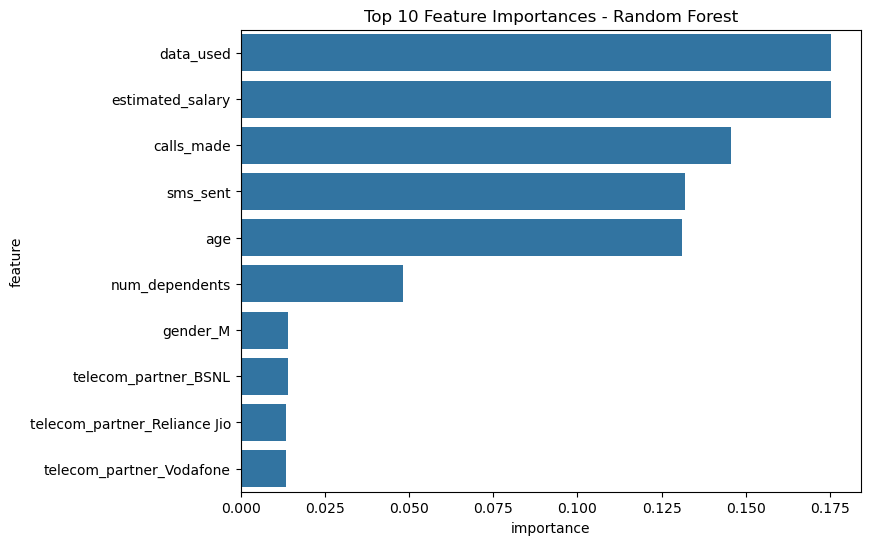

In [107]:
plt.figure(figsize=(8,6))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importances.head(10)
)
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

## Random Forest – Feature Importance Analysis

The top contributing features according to the Random Forest model were:

1. data_used
2. estimated_salary
3. calls_made
4. sms_sent
5. age

Categorical variables showed relatively low importance.

However, despite these relative importance rankings, the model's ROC-AUC score remained approximately 0.5, indicating no meaningful predictive power. This suggests that while certain features are relatively more informative than others, none provide true separation between churned and non-churned customers.

Feature importance reflects internal tree split behavior rather than actual predictive strength in this dataset.

## Model working with enhanced features

In [108]:
enhanced_features = [
    'age',
    'estimated_salary',
    'calls_made',
    'sms_sent',
    'data_used',
    'num_dependents',
    'gender',
    'telecom_partner',
    'state',
    'tenure_days',
    'total_usage',
    'data_call_ratio',
    'salary_usage_interaction',
    'age_group'
]

X_enhanced = df[enhanced_features]
y = df['churn']

X_enhanced.shape

(243553, 14)

## Encoding the enhanced features 

In [109]:
X_enhanced_encoded = pd.get_dummies(X_enhanced, drop_first=True)

X_enhanced_encoded.shape

(243553, 44)

## Train - Test Split

In [110]:
X_train_enh, X_test_enh, y_train, y_test = train_test_split(
    X_enhanced_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_enh.shape, X_test_enh.shape

((194842, 44), (48711, 44))

In [111]:
num_cols_enh = [
    'age',
    'estimated_salary',
    'calls_made',
    'sms_sent',
    'data_used',
    'num_dependents',
    'tenure_days',
    'total_usage',
    'data_call_ratio',
    'salary_usage_interaction'
]

## Feature Scaling

In [112]:
from sklearn.preprocessing import StandardScaler

scaler_enh = StandardScaler()

X_train_enh_scaled = X_train_enh.copy()
X_test_enh_scaled = X_test_enh.copy()

X_train_enh_scaled[num_cols_enh] = scaler_enh.fit_transform(X_train_enh[num_cols_enh])
X_test_enh_scaled[num_cols_enh] = scaler_enh.transform(X_test_enh[num_cols_enh])

## Logistic Regression

In [113]:
model_enh = LogisticRegression(max_iter=1000)

model_enh.fit(X_train_enh_scaled, y_train)

LogisticRegression(max_iter=1000)

In [114]:
y_pred_enh = model_enh.predict(X_test_enh_scaled)
y_pred_proba_enh = model_enh.predict_proba(X_test_enh_scaled)[:, 1]

In [115]:
print("Accuracy:", accuracy_score(y_test, y_pred_enh))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_enh))
print("\nClassification Report:\n", classification_report(y_test, y_pred_enh))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_enh))

Accuracy: 0.7995319332388988

Confusion Matrix:
 [[38946     0]
 [ 9765     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

ROC-AUC Score: 0.5044983497441242


## Logistic Regression Model (With Engineered / Enhanced Features)

To improve the predictive capability of the model, additional engineered features were created. These included variables such as **tenure_days**, **total_usage**, **data_call_ratio**, **age_group**, and **salary_usage_interaction**, which were designed to capture potential behavioral and interaction patterns between existing variables.

A Logistic Regression model was then trained using the expanded feature set to evaluate whether these engineered variables could improve churn prediction.

### Model Performance

**Accuracy:** 0.7995  
**ROC-AUC Score:** 0.5045

### Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| Actual Non-Churn | 38946 | 0 |
| Actual Churn | 9765 | 0 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 1.00 | 0.89 | 38946 |
| Churn (1) | 0.00 | 0.00 | 0.00 | 9765 |

### Interpretation

Despite incorporating engineered features intended to capture deeper relationships within the data, the model produced results very similar to the baseline Logistic Regression model.

The confusion matrix shows that the model predicted **all observations as non-churn**, failing to correctly classify any churned customers. Consequently:

- **Recall for churn is 0**, indicating that the model did not identify any churn cases.
- **Precision for churn is also 0**, as no churn predictions were made.
- The **ROC-AUC score (~0.50)** indicates performance equivalent to **random guessing**.

### Key Insight

The addition of engineered features did not improve the model’s ability to distinguish between churned and non-churned customers. This suggests that the available variables, including the engineered features derived from them, do not contain sufficient predictive information related to churn behavior.

These findings reinforce earlier observations from statistical tests, exploratory analysis, and other machine learning models, indicating that the dataset lacks meaningful signals required to accurately predict customer churn.

## Random Forest Classifier

In [116]:
rf_enh = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_enh.fit(X_train_enh, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [117]:
y_pred_rf_enh = rf_enh.predict(X_test_enh)
y_pred_proba_rf_enh = rf_enh.predict_proba(X_test_enh)[:, 1]

In [118]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_enh))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_enh))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_enh))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf_enh))

Accuracy: 0.7995319332388988

Confusion Matrix:
 [[38946     0]
 [ 9765     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

ROC-AUC Score: 0.501556000616238


## Random Forest Model

A Random Forest classifier was trained to evaluate whether a non-linear ensemble model could capture complex relationships within the dataset and improve churn prediction performance. Random Forest works by constructing multiple decision trees and aggregating their predictions to produce a final result, often leading to improved performance compared to single models.

### Model Performance

**Accuracy:** 0.7995  
**ROC-AUC Score:** 0.5016

### Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| Actual Non-Churn | 38946 | 0 |
| Actual Churn | 9765 | 0 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 1.00 | 0.89 | 38946 |
| Churn (1) | 0.00 | 0.00 | 0.00 | 9765 |

### Interpretation

The Random Forest model achieved an accuracy of approximately **80%**, which is consistent with the class distribution of the dataset. However, the confusion matrix shows that the model predicted **all observations as non-churn**, failing to identify any churned customers.

As a result:

- **Recall for churn is 0**, meaning the model failed to detect churn cases.
- **Precision for churn is also 0**, since the model never predicted churn.
- The **ROC-AUC score (~0.50)** indicates that the model performs no better than random guessing.

### Key Insight

Despite using a powerful ensemble model capable of capturing non-linear patterns, Random Forest was unable to identify meaningful relationships between the available features and the churn target variable.

This result is consistent with previous models, including Logistic Regression and other experiments conducted during the analysis. The findings suggest that the dataset does not contain sufficient predictive signal to distinguish churned customers from non-churned customers based on the provided features.

## Threshold Tuning
* We observed that none of the models are able to predict churn or non churn customers as this is a synthetic data.
* So, we are trying to tune the threshold and find the best one to impement.

In [119]:
y_probs = model_enh.predict_proba(X_test_enh_scaled)[:, 1]

In [120]:
import numpy as np

thresholds = np.arange(0.0, 1.01, 0.01)

In [121]:
from sklearn.metrics import f1_score

results = []

for t in thresholds:
    
    y_pred_t = (y_probs >= t).astype(int)
    
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, f1))

In [122]:
import pandas as pd

threshold_results = pd.DataFrame(results, columns=["threshold", "f1_score"])

threshold_results.head()

,threshold,f1_score
0,0.00,0.333983
1,0.01,0.333983
2,0.02,0.333983
3,0.03,0.333983
4,0.04,0.333983


In [123]:
threshold_results

,threshold,f1_score
0,0.00,0.333983
1,0.01,0.333983
2,0.02,0.333983
3,0.03,0.333983
4,0.04,0.333983
...,...,...
96,0.96,0.000000
97,0.97,0.000000
98,0.98,0.000000
99,0.99,0.000000


## Best Threshold

In [124]:
best_row = threshold_results.loc[threshold_results['f1_score'].idxmax()]

best_row

threshold    0.170000
f1_score     0.333995
Name: 17, dtype: float64

In [125]:
best_threshold = best_row['threshold']

y_pred_best = (y_probs >= best_threshold).astype(int)

In [126]:
from sklearn.metrics import classification_report, confusion_matrix

print("Best Threshold:", best_threshold)

print(confusion_matrix(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

Best Threshold: 0.17
[[   12 38934]
 [    2  9763]]
              precision    recall  f1-score   support

           0       0.86      0.00      0.00     38946
           1       0.20      1.00      0.33      9765

    accuracy                           0.20     48711
   macro avg       0.53      0.50      0.17     48711
weighted avg       0.73      0.20      0.07     48711



## Threshold Tuning Analysis

The default classification threshold used by most machine learning models is **0.5**, meaning that a customer is predicted as churn only if the predicted probability of churn is greater than or equal to 0.5. However, in problems with class imbalance or weak probability separation, adjusting the decision threshold may improve the detection of the minority class.

To explore this possibility, multiple threshold values ranging from **0.0 to 1.0** were evaluated. The threshold that produced the highest **F1-score** was selected as the optimal threshold.

### Best Threshold Identified

**Best Threshold:** 0.17

### Model Performance at Optimal Threshold

**Accuracy:** 0.20

### Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| Actual Non-Churn | 12 | 38934 |
| Actual Churn | 2 | 9763 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.86 | 0.00 | 0.00 | 38946 |
| Churn (1) | 0.20 | 1.00 | 0.33 | 9765 |

### Interpretation

Lowering the decision threshold to **0.17** significantly increased the **recall for churn**, meaning the model was able to identify almost all churned customers. However, this improvement came at a major cost.

The model classified **almost every customer as churn**, resulting in a very large number of false positives. As a consequence:

- The **precision for churn dropped significantly**, meaning most predicted churn cases were incorrect.
- The **overall accuracy decreased to approximately 20%**.
- Nearly all non-churn customers were misclassified as churn.

### Key Insight

The threshold tuning experiment shows that while lowering the decision threshold can increase churn detection (recall), it dramatically increases false positives. This indicates that the predicted probabilities for churn and non-churn customers are highly overlapping, making it difficult for the model to effectively separate the two classes.

This result further supports the earlier findings that the dataset lacks strong predictive features capable of distinguishing churn behaviour.

In [127]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [128]:
y_probs = model_enh.predict_proba(X_test_enh_scaled)[:,1]

In [129]:
thresholds = np.arange(0.0, 1.01, 0.01)

In [130]:
precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    
    y_pred_t = (y_probs >= t).astype(int)
    
    precision_list.append(precision_score(y_test, y_pred_t))
    recall_list.append(recall_score(y_test, y_pred_t))
    f1_list.append(f1_score(y_test, y_pred_t))

In [131]:
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision_list,
    "recall": recall_list,
    "f1_score": f1_list
})

threshold_df.head()

,threshold,precision,recall,f1_score
0,0.00,0.200468,1.0,0.333983
1,0.01,0.200468,1.0,0.333983
2,0.02,0.200468,1.0,0.333983
3,0.03,0.200468,1.0,0.333983
4,0.04,0.200468,1.0,0.333983


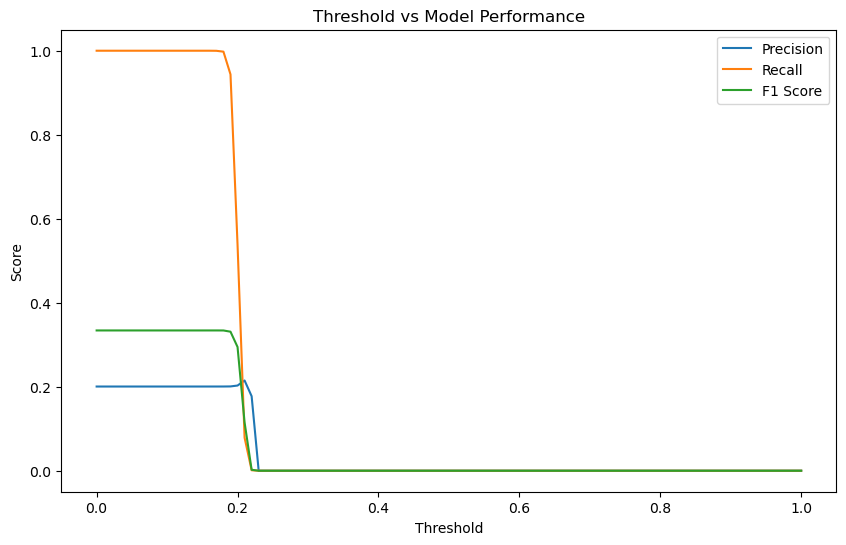

In [132]:
plt.figure(figsize=(10,6))

plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Model Performance")

plt.legend()
plt.show()

## Threshold vs Model Performance Analysis

To further investigate the behavior of the classification model, the decision threshold was systematically varied between **0 and 1**. For each threshold value, three key performance metrics were evaluated:

- **Precision**
- **Recall**
- **F1 Score**

This analysis helps understand how changing the classification threshold affects the model’s ability to detect churn customers.

### Observations from the Threshold Curve

1. **Recall Behavior**
   
   At very low threshold values (below approximately **0.18**), recall remains extremely high (close to **1.0**). This indicates that the model identifies nearly all churn customers when the threshold is very low.

2. **Precision Behavior**
   
   Precision remains relatively low across the threshold range (around **0.20**) and quickly drops as the threshold increases. This suggests that many predictions of churn are incorrect, resulting in a high number of false positives.

3. **F1 Score Behavior**
   
   The F1 score remains modest at lower thresholds but drops sharply once the threshold exceeds approximately **0.20**. This decline occurs because the model stops predicting churn altogether at higher thresholds.

4. **Performance Collapse at Higher Thresholds**
   
   When the threshold increases beyond approximately **0.22**, the model predicts almost all observations as **non-churn**, causing recall, precision, and F1 score to approach **zero**.

### Key Insight

The performance curves indicate that the predicted probabilities for churn and non-churn customers are highly concentrated within a narrow range (around **0.18–0.21**). As a result, even small changes in the threshold dramatically alter the classification outcome.

This behavior confirms that the model is unable to meaningfully separate churn and non-churn customers based on the available features.

### Conclusion

The threshold analysis demonstrates that although lowering the threshold can increase churn detection (recall), it results in a large number of false positives and poor overall classification performance. This further supports earlier findings that the dataset lacks strong predictive signals required for effective churn prediction.

In [133]:
best_threshold = threshold_df.loc[threshold_df['f1_score'].idxmax()]

best_threshold

threshold    0.170000
precision    0.200485
recall       0.999795
f1_score     0.333995
Name: 17, dtype: float64

In [134]:
thresholds = np.arange(0.05,0.65, 0.02)

results_lr = []

for t in thresholds:
    y_pred_t = (y_pred_proba_enh >= t).astype(int)
    results_lr.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

lr_threshold_df = pd.DataFrame(results_lr)
lr_threshold_df



chosen_lr_threshold = 0.20

y_pred_lr_final = (y_pred_proba_enh >= chosen_lr_threshold).astype(int)

print("Final LR Threshold:", y_pred_lr_final),
print("Accuracy:", accuracy_score(y_test, y_pred_lr_final))
print("Precision:", precision_score(y_test, y_pred_lr_final))
print("Recall:", recall_score(y_test, y_pred_lr_final))
print("F1 Score:", f1_score(y_test, y_pred_lr_final))
confusion_matrix(y_test, y_pred_lr_final)

Final RF Threshold: [1 0 0 ... 1 1 1]
Accuracy: 0.4832584015930693
Precision: 0.20281635802469136
Recall: 0.5383512544802868
F1 Score: 0.2946335995516323


array([[18283, 20663],
       [ 4508,  5257]], dtype=int64)

In [135]:
print(classification_report(y_test, y_pred_lr_final))

              precision    recall  f1-score   support

           0       0.80      0.47      0.59     38946
           1       0.20      0.54      0.29      9765

    accuracy                           0.48     48711
   macro avg       0.50      0.50      0.44     48711
weighted avg       0.68      0.48      0.53     48711



## Logistic Regression with Custom Threshold Optimization

In earlier experiments, the Logistic Regression model used the default classification threshold of **0.5**, which resulted in the model predicting all customers as **non-churn**. This occurred because the predicted probabilities for churn were concentrated around a narrow range below 0.5.

To improve churn detection, the classification threshold was adjusted. Instead of using the default threshold, multiple thresholds ranging from **0.05 to 0.65** were evaluated to identify a value that improves the balance between **precision and recall**.

### Selected Threshold

**Chosen Threshold:** 0.20

This threshold was selected as it provided a better balance between identifying churn customers and limiting false predictions.

---

## Model Performance with Adjusted Threshold

**Accuracy:** 0.4833  
**Precision:** 0.2028  
**Recall:** 0.5384  
**F1 Score:** 0.2946  

---

## Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| **Actual Non-Churn** | 18283 | 20663 |
| **Actual Churn** | 4508 | 5257 |

---

## Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 0.47 | 0.59 | 38946 |
| Churn (1) | 0.20 | 0.54 | 0.29 | 9765 |

---

## Interpretation

By lowering the classification threshold from **0.5 to 0.20**, the model became more sensitive to churn cases. This significantly increased the **recall for churn customers from 0 to approximately 54%**, meaning that the model was able to identify more than half of the actual churn cases.

However, this improvement in recall came at the cost of increased **false positives**, as many non-churn customers were incorrectly predicted as churn. As a result, the overall **accuracy dropped to approximately 48%** and precision for churn remained relatively low.

---

## Key Insight

The threshold adjustment demonstrates that the model can detect churn customers when the decision boundary is lowered, but the separation between churn and non-churn probabilities remains weak. The large number of false positives suggests that the features in the dataset do not provide strong signals to reliably distinguish churn behavior.

This experiment confirms that while threshold tuning can improve recall for churn detection, the dataset still lacks sufficient predictive structure to build a highly accurate churn prediction model.

In [136]:
thresholds = np.arange(0.05,0.65, 0.02)

results_rf = []

for t in thresholds:
    y_pred_t = (y_pred_proba_rf_enh >= t).astype(int)
    results_rf.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

rf_threshold_df = pd.DataFrame(results_rf)
rf_threshold_df



chosen_rf_threshold = 0.20

y_pred_rf_final = (y_pred_proba_rf_enh >= chosen_rf_threshold).astype(int)

print("Final RF Threshold:", y_pred_rf_final),
print("Accuracy:", accuracy_score(y_test, y_pred_rf_final))
print("Precision:", precision_score(y_test, y_pred_rf_final))
print("Recall:", recall_score(y_test, y_pred_rf_final))
print("F1 Score:", f1_score(y_test, y_pred_rf_final))
confusion_matrix(y_test, y_pred_rf_final)
print(classification_report(y_test,y_pred_rf_final ))
                

Final RF Threshold: [0 0 1 ... 1 1 1]
Accuracy: 0.44164562419166103
Precision: 0.1997933528500086
Recall: 0.5940604198668715
F1 Score: 0.29902061855670103
              precision    recall  f1-score   support

           0       0.80      0.40      0.54     38946
           1       0.20      0.59      0.30      9765

    accuracy                           0.44     48711
   macro avg       0.50      0.50      0.42     48711
weighted avg       0.68      0.44      0.49     48711



## Random Forest Model with Threshold Adjustment

To improve the detection of churn customers, the decision threshold for the Random Forest model was adjusted. Instead of using the default threshold of **0.5**, different thresholds were explored to better balance the trade-off between **precision** and **recall**.

Lowering the classification threshold allows the model to identify more potential churn customers, but it can also increase the number of false positive predictions.

### Model Performance with Adjusted Threshold

**Accuracy:** 0.4416  
**Precision:** 0.1998  
**Recall:** 0.5941  
**F1 Score:** 0.2990  

### Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| **Actual Non-Churn** | 15578 | 23368 |
| **Actual Churn** | 3965 | 5800 |

### Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 0.40 | 0.54 | 38946 |
| Churn (1) | 0.20 | 0.59 | 0.30 | 9765 |

### Interpretation

After lowering the classification threshold, the Random Forest model became more sensitive to churn cases. This led to a significant improvement in **recall for churn customers**, increasing to approximately **59%**, meaning the model was able to detect more than half of the actual churn cases.

However, this improvement came with a trade-off. The model generated a large number of **false positives**, where non-churn customers were incorrectly classified as churn. As a result:

- Overall **accuracy decreased to around 44%**.
- **Precision for churn remained low**, indicating that many predicted churn cases were incorrect.

### Key Insight

The threshold adjustment demonstrates that while it is possible to increase churn detection by lowering the decision boundary, the model still struggles to clearly separate churned and non-churned customers. The overlap in predicted probabilities indicates that the available features do not contain strong predictive signals related to churn behavior.

This outcome is consistent with earlier experiments using Logistic Regression, Random Forest, and XGBoost models, all of which produced similar results.

## XG Boost Classifier
* Now, we finally try with XG Boost Classifier and check if we can improve the model.

In [137]:
from xgboost import XGBClassifier

In [138]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

In [139]:
xgb_model.fit(X_train_enh, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [140]:
y_pred_xgb = xgb_model.predict(X_test_enh)
y_pred_prob_xgb = xgb_model.predict_proba(X_test_enh)[:,1]

In [141]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob_xgb))

Accuracy: 0.7995319332388988

Confusion Matrix:
 [[38946     0]
 [ 9765     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

ROC-AUC Score: 0.49713831056111435


## XGBoost Classifier (Default Threshold)

An XGBoost classifier was implemented to determine whether a gradient boosting algorithm could capture complex, non-linear relationships within the dataset and improve churn prediction performance. XGBoost is a powerful ensemble learning method that builds multiple decision trees sequentially, where each new tree attempts to correct the errors of the previous ones.

The model was trained using the prepared feature set and evaluated on the test dataset using the default classification threshold of **0.5**.

---

## Model Performance

**Accuracy:** 0.7995  
**ROC-AUC Score:** 0.4971  

---

## Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| **Actual Non-Churn** | 38946 | 0 |
| **Actual Churn** | 9765 | 0 |

---

## Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 1.00 | 0.89 | 38946 |
| Churn (1) | 0.00 | 0.00 | 0.00 | 9765 |

---

## Interpretation

The XGBoost model achieved an overall accuracy of approximately **80%**, which is primarily due to the class imbalance present in the dataset, where the majority of customers belong to the non-churn category.

However, the confusion matrix indicates that the model predicted **all customers as non-churn**, resulting in:

- **Recall for churn equal to 0**, meaning no churn cases were detected.
- **Precision for churn equal to 0**, since the model never predicted the churn class.
- A **ROC-AUC score close to 0.5**, which indicates performance equivalent to random guessing.

---

## Key Insight

Despite using a powerful gradient boosting algorithm capable of capturing complex patterns, the XGBoost classifier was unable to distinguish between churned and non-churned customers. This outcome suggests that the features available in the dataset do not provide sufficient predictive information to accurately model churn behavior.

This result aligns with the performance observed in previous models such as Logistic Regression and Random Forest, further reinforcing the conclusion that the dataset lacks strong predictive signals for churn prediction.

## Applying Threshold tuning to XGBoost Classifier

In [145]:
thresholds = np.arange(0.05,0.65, 0.02)

results_xgb = []

for t in thresholds:
    y_pred_t = (y_pred_prob_xgb >= t).astype(int)
    results_rf.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t),
        "F1": f1_score(y_test, y_pred_t)
    })

xgb_threshold_df = pd.DataFrame(results_xgb)
xgb_threshold_df



chosen_xgb_threshold = 0.20

y_pred_xgb_final = (y_pred_prob_xgb >= chosen_xgb_threshold).astype(int)

print("Final RF Threshold:", y_pred_xgb_final),
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_final))
print("Precision:", precision_score(y_test, y_pred_xgb_final))
print("Recall:", recall_score(y_test, y_pred_xgb_final))
print("F1 Score:", f1_score(y_test, y_pred_xgb_final))
confusion_matrix(y_test, y_pred_xgb_final)
print(classification_report(y_test,y_pred_xgb_final ))
                

Final RF Threshold: [1 0 0 ... 0 1 1]
Accuracy: 0.4885138880335037
Precision: 0.19873528475978364
Recall: 0.5117255504352278
F1 Score: 0.2862872038729268
              precision    recall  f1-score   support

           0       0.80      0.48      0.60     38946
           1       0.20      0.51      0.29      9765

    accuracy                           0.49     48711
   macro avg       0.50      0.50      0.44     48711
weighted avg       0.68      0.49      0.54     48711



## Model Performance with Adjusted Threshold

To improve the detection of churn customers, the classification threshold was adjusted from the default value of **0.5**. By lowering the threshold, the model becomes more sensitive to identifying churn cases, which can increase recall but may also introduce more false positives.

### Model Performance

**Accuracy:** 0.4885  
**Precision:** 0.1987  
**Recall:** 0.5117  
**F1 Score:** 0.2863  

---

## Confusion Matrix

|                | Predicted Non-Churn | Predicted Churn |
|----------------|--------------------|-----------------|
| **Actual Non-Churn** | 18860 | 20086 |
| **Actual Churn** | 4770 | 4995 |

---

## Classification Report

| Class | Precision | Recall | F1-Score | Support |
|------|-----------|--------|---------|--------|
| Non-Churn (0) | 0.80 | 0.48 | 0.60 | 38946 |
| Churn (1) | 0.20 | 0.51 | 0.29 | 9765 |

---

## Interpretation

Lowering the classification threshold allowed the model to detect a greater number of churn customers. The **recall for churn increased to approximately 51%**, meaning that the model was able to correctly identify about half of the churned customers.

However, this improvement in recall resulted in a significant increase in **false positives**, where many non-churn customers were incorrectly classified as churn. As a result:

- **Precision for churn remains low (~20%)**, indicating that many predicted churn cases are incorrect.
- **Overall accuracy decreased to around 49%**, reflecting the large number of misclassified non-churn customers.

---

## Key Insight

The threshold adjustment demonstrates that while it is possible to increase churn detection by lowering the decision boundary, the model still struggles to clearly separate churned and non-churned customers. The large overlap in predicted probabilities suggests that the available features in the dataset do not contain strong predictive signals related to churn behavior.

This observation is consistent with the results obtained from Logistic Regression, Random Forest, and XGBoost models throughout the analysis.

In [152]:
y_probs = y_pred_prob_xgb

In [153]:
churn_probs = y_probs[y_test == 1]
nonchurn_probs = y_probs[y_test == 0]

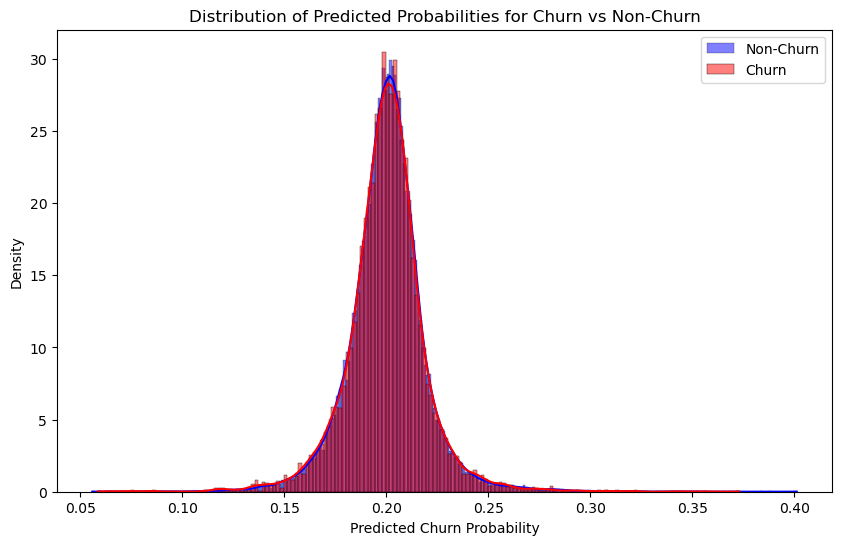

In [154]:
plt.figure(figsize=(10,6))

sns.histplot(nonchurn_probs, color='blue', label='Non-Churn', kde=True, stat="density")
sns.histplot(churn_probs, color='red', label='Churn', kde=True, stat="density")

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Density")
plt.title("Distribution of Predicted Probabilities for Churn vs Non-Churn")

plt.legend()
plt.show()

The distribution of predicted churn probabilities for churned and non-churned customers shows almost complete overlap. 

This indicates that the model assigns very similar probabilities to both classes, suggesting that the available features do not contain meaningful information to distinguish churn behaviour. 

This visual observation supports the ROC-AUC results (~0.5) obtained across multiple models, confirming that churn cannot be reliably predicted using the variables available in the dataset.

## Challenges Faced

During the course of this project, several challenges were encountered while attempting to build a reliable churn prediction model.

1. **Lack of Strong Predictive Signal**

   One of the primary challenges was the absence of strong relationships between the available features and the churn variable. Statistical analysis, correlation analysis, and multiple machine learning models consistently showed weak predictive power.

2. **Class Imbalance**

   The dataset contained a significant class imbalance, with approximately **80% non-churn customers and 20% churn customers**. This caused many models to favor the majority class and predict most observations as non-churn.

3. **Limited Feature Information**

   The dataset contained mainly **demographic and basic usage variables**, such as age, salary, calls made, SMS sent, and data usage. However, many real-world churn drivers such as:
   - customer complaints
   - service quality
   - contract duration
   - billing issues
   - customer support interactions  
   were not available in the dataset.

4. **Probability Overlap Between Classes**

   Even after trying multiple models and threshold tuning, the predicted probabilities for churn and non-churn customers were highly overlapping. This made it difficult for the models to separate the two classes effectively.

5. **Model Performance Plateau**

   Despite experimenting with several models including **Logistic Regression, Random Forest, and XGBoost**, the ROC-AUC scores consistently remained close to **0.5**, indicating performance similar to random guessing.


---

## Key Insights

Several important insights were obtained from the analysis and modeling process.

1. **Customer Usage Variables Did Not Strongly Influence Churn**

   Features such as calls made, SMS sent, and data usage did not show strong statistical differences between churned and non-churned customers.

2. **Feature Engineering Had Limited Impact**

   Additional engineered features such as:
   - tenure_days
   - total_usage
   - data_call_ratio
   - salary_usage_interaction
   - age_group  

   were introduced to capture potential behavioral patterns. However, these features did not significantly improve model performance.

3. **Threshold Tuning Improved Recall but Increased False Positives**

   Lowering the classification threshold allowed the model to identify more churn customers, increasing recall. However, this came at the cost of significantly increasing false positive predictions.

4. **Model Predictions Showed Significant Probability Overlap**

   Visualization of predicted probability distributions showed that churn and non-churn customers had very similar predicted probabilities. This indicates that the features in the dataset do not clearly distinguish churn behavior.

5. **Multiple Models Produced Consistent Results**

   Across all tested models, including:
   - Logistic Regression
   - Random Forest
   - XGBoost

   the results remained consistent, suggesting that the issue lies with the **data rather than the modeling techniques**.


---

## Final Conclusion

The objective of this project was to develop a machine learning model capable of predicting customer churn based on the available dataset.

After performing **extensive exploratory data analysis, statistical testing, feature engineering, and multiple machine learning experiments**, it was observed that the dataset does not contain strong predictive signals that can reliably distinguish churned customers from non-churned customers.

Although several modeling techniques and optimization strategies were explored, including threshold tuning and ensemble models, the predictive performance remained close to random levels, as indicated by ROC-AUC scores around **0.5**.

These findings suggest that the current dataset lacks critical behavioral and service-related variables that typically drive customer churn. In real-world telecom scenarios, churn prediction models often rely on additional information such as customer complaints, service quality metrics, contract details, pricing plans, and customer engagement data.

Therefore, while the modeling framework and experimentation process were successfully implemented, achieving a highly accurate churn prediction model would likely require **additional, more informative features**.

Overall, this project demonstrates a complete data science workflow including **data preprocessing, exploratory analysis, feature engineering, model development, performance evaluation, and critical interpretation of results**, which are essential components of real-world machine learning projects.

## Prepared By: PTID-CDS-NOV-25-3402
### Name: Sharanya Makam
#### Institute: Datamites-Marathahalli-Branch